In [1]:
"""Environment setup and library imports for Conv1D training.

Sets Keras JAX backend and configures JAX precision and memory allocation behavior.
"""

import glob
import os
import pickle
import random
import warnings

os.environ["KERAS_BACKEND"] = "jax"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.7"

import jax

# Enable JAX float64 precision natively
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import keras
from keras import callbacks, layers, regularizers
import numpy as np
import polars as pl

warnings.filterwarnings("ignore")

# Show enough digits to round-trip float64 diagnostics
np.set_printoptions(precision=17, floatmode="unique")

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Keras backend : {keras.backend.backend()}")
print(f"Working dir   : {os.getcwd()}")


2026-08-04 15:34:54.403949: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785846894.445851  143048 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785846894.458567  143048 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras version : 3.12.0
Keras backend : jax
Working dir   : /home/samer/Documents/competitions/ROGII/notebooks


In [2]:
def find_data_dir() -> str:
    """Searches common Kaggle and local mount points for the ROGII dataset.

    Returns:
        str: Path to the dataset directory containing 'train' subdirectory.

    Raises:
        FileNotFoundError: If the dataset cannot be found in any candidate path.
    """
    candidates = [
        "/kaggle/input/competitions/rogii-wellbore-geology-prediction",
        "/kaggle/input/rogii-wellbore-geology-prediction",
        "/home/samer/Documents/competitions/ROGII/dataset",
    ]

    for scan_root in ["/kaggle/input", "/kaggle/input/competitions"]:
        if os.path.isdir(scan_root):
            for entry in os.listdir(scan_root):
                full = os.path.join(scan_root, entry)
                if os.path.isdir(full) and full not in candidates:
                    candidates.append(full)

    print("Searching for ROGII dataset...")
    for path in candidates:
        if not os.path.isdir(path):
            continue

        contents = os.listdir(path)
        has_train = "train" in contents and os.path.isdir(os.path.join(path, "train"))
        n_train = 0
        if has_train:
            n_train = len(
                glob.glob(os.path.join(path, "train", "*__horizontal_well.csv"))
            )

        if n_train > 0:
            print(f"  V Using {path} (found {n_train} train wells)")
            return path

    raise FileNotFoundError("Could not find ROGII dataset.")


DATA_DIR = find_data_dir()


Searching for ROGII dataset...
  V Using /home/samer/Documents/competitions/ROGII/dataset (found 773 train wells)


### Data preparation

In [3]:
"""Data loading, preprocessing and preparation functions using Polars and JAX.

The Conv1D model is trained with a test-like TVT_input mask. In the competition test
wells, TVT_input is known before the submission interval and missing throughout the
interval that must be predicted. If validation keeps the true TVT_input, the model can
learn an identity shortcut and report unrealistically low validation RMSE.

This version applies robust shifted log-normalization to avoid NaN values caused by
negative coordinate/depth values (e.g. Z elevation).
"""

from typing import Dict, List, Tuple, Union
import glob
import os
import pickle
import jax
import jax.numpy as jnp
import numpy as np
import polars as pl

FEATURE_COLS: List[str] = ["MD", "X", "Y", "Z", "GR", "TVT_input"]
TARGET: str = "TVT"
TVT_INPUT_COL: str = "TVT_input"
MASK_START_RATIO_RANGE: Tuple[float, float] = (0.20, 0.40)


def mask_tvt_input_for_prediction_zone(
    df: pl.DataFrame,
    rng: np.random.Generator,
    ratio_range: Tuple[float, float] = MASK_START_RATIO_RANGE,
) -> Tuple[pl.DataFrame, int]:
    """Masks a suffix of TVT_input to mimic the hidden test prediction interval.

    Args:
        df (pl.DataFrame): Input DataFrame containing the well data.
        rng (np.random.Generator): Random number generator for reproducibility.
        ratio_range (Tuple[float, float]): Range of mask start ratio relative
          to well depth.

    Returns:
        Tuple[pl.DataFrame, int]: A tuple containing the masked DataFrame and
          the index where the masking started.
    """
    if TVT_INPUT_COL not in df.columns or len(df) < 2:
        return df, len(df)

    low, high = ratio_range
    mask_start = int(round(len(df) * rng.uniform(low, high)))
    mask_start = min(max(mask_start, 1), len(df) - 1)
    row_nr = pl.int_range(0, pl.len())
    df = df.with_columns(
        pl.when(row_nr >= mask_start)
        .then(None)
        .otherwise(pl.col(TVT_INPUT_COL))
        .alias(TVT_INPUT_COL)
    )
    return df, mask_start


def preprocess(df: pl.DataFrame) -> pl.DataFrame:
    """Interpolates and fills null values in the feature columns.

    Args:
        df (pl.DataFrame): Input DataFrame with missing values.

    Returns:
        pl.DataFrame: Preprocessed DataFrame with all feature columns filled.
    """
    for col in FEATURE_COLS:
        if col in df.columns:
            df = df.with_columns(
                pl.col(col)
                .interpolate()
                .fill_null(strategy="forward")
                .fill_null(strategy="backward")
                .fill_null(0.0)
            )
    return df


def prepare_data(
    data_dir: str,
    val_ratio: float = 0.20,
    seed: int = 42,
    max_wells: Union[int, None] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict]:
    """Loads wells and builds train/validation arrays with test-like masking.

    Applies shifted log1p transformation and Z-score standardization using JAX to handle
    negative feature values (such as Z depth) while maintaining normalized distributions.

    Args:
        data_dir (str): Path to the training dataset.
        val_ratio (float): Fraction of wells to use for validation.
        seed (int): Random seed for split and masking reproducibility.
        max_wells (Union[int, None]): Maximum number of wells to load (for debugging).

    Returns:
        Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict]:
          A tuple containing:
            - X_train: Preprocessed standardized training features (3D: [samples, 1, features]).
            - y_train: Standardized training target values (1D: [samples]).
            - X_val: Preprocessed standardized validation features (3D: [samples, 1, features]).
            - y_val: Standardized validation target values (1D: [samples]).
            - y_val_raw: Raw validation targets in original scale (1D: [samples]).
            - scaler: Dictionary containing standardization scaling parameters.
    """
    dataset_root = os.path.dirname(data_dir)

    # 1. Get original training IDs
    pattern_train = os.path.join(data_dir, "train", "*__horizontal_well.csv")
    files_train = sorted([os.path.basename(f) for f in glob.glob(pattern_train)])

    files_train_all = files_train

    if max_wells:
        files_train_all = files_train_all[:max_wells]

    rng = np.random.default_rng(seed)
    n_val = max(1, int(len(files_train_all) * val_ratio))
    val_set = set(rng.permutation(len(files_train_all))[:n_val])

    train_files = [fname for i, fname in enumerate(files_train_all) if i not in val_set]
    val_files = [fname for i, fname in enumerate(files_train_all) if i in val_set]

    print(f"Loading {len(files_train_all)} training wells total.")

    def get_arrays(files: List[str], split_name: str) -> Tuple[np.ndarray, np.ndarray]:
        """Reads CSV files for a split, masks TVT_input, and returns merged arrays.

        Args:
            files (List[str]): List of filenames to load.
            split_name (str): Label for the dataset split (e.g. "Train", "Val").

        Returns:
            Tuple[np.ndarray, np.ndarray]: Merged features and target arrays.
        """
        feats, tgts, mask_starts = [], [], []
        for filename in files:
            try:
                path = os.path.join(data_dir, "train", filename)

                df = pl.read_csv(path, infer_schema_length=10000)
                df = df.filter(pl.col(TARGET).is_not_null())
                if len(df) == 0:
                    continue

                df, mask_start = mask_tvt_input_for_prediction_zone(df, rng)
                df = preprocess(df)

                feats.append(df.select(FEATURE_COLS).to_numpy().astype(np.float64))
                tgts.append(df.select(TARGET).to_numpy().ravel().astype(np.float64))
                mask_starts.append(mask_start / len(df))
            except Exception as e:
                print(f"  Skip {filename}: {e}")

        if not feats:
            raise ValueError(f"No usable wells found for {split_name} split.")

        print(
            f"{split_name} TVT_input mask start ratio: "
            f"mean={np.mean(mask_starts):.3f}, "
            f"min={np.min(mask_starts):.3f}, max={np.max(mask_starts):.3f}"
        )
        return np.concatenate(feats), np.concatenate(tgts)

    X_train_raw, y_train_raw = get_arrays(train_files, "Train")
    X_val_raw, y_val_raw = get_arrays(val_files, "Val")

    cpu_dev = jax.devices("cpu")[0]
    X_tr_jax = jax.device_put(X_train_raw, cpu_dev)
    y_tr_jax = jax.device_put(y_train_raw, cpu_dev)
    X_val_jax = jax.device_put(X_val_raw, cpu_dev)
    y_val_jax = jax.device_put(y_val_raw, cpu_dev)

    # 1. Compute non-negative shifts for features so min(X + shift) >= 0 before log1p
    feat_min = jnp.min(X_tr_jax, axis=0)
    feat_shifts = jnp.where(feat_min < 0, -feat_min, 0.0)

    # 2. Apply log1p transformation using JAX
    print("Applying shifted log1p transformation...")
    X_train_log = jnp.log1p(X_tr_jax + feat_shifts)
    X_val_log = jnp.log1p(X_val_jax + feat_shifts)
    y_train_log = jnp.log1p(y_tr_jax)
    y_val_log = jnp.log1p(y_val_jax)

    # 3. Compute mean & std of log-transformed features and target for Z-score standardization
    feat_log_mean = jnp.mean(X_train_log, axis=0)
    feat_log_std = jnp.std(X_train_log, axis=0)
    feat_log_std = jnp.where(feat_log_std == 0, 1.0, feat_log_std)

    target_log_mean = float(jnp.mean(y_train_log))
    target_log_std = float(jnp.std(y_train_log))
    if target_log_std == 0:
        target_log_std = 1.0

    # 4. Standardize log features and target
    X_train_n = (X_train_log - feat_log_mean) / feat_log_std
    y_train_n = (y_train_log - target_log_mean) / target_log_std
    X_val_n = (X_val_log - feat_log_mean) / feat_log_std
    y_val_n = (y_val_log - target_log_mean) / target_log_std

    # Sanity check for non-finite values
    print(f"Train X has NaNs: {jnp.isnan(X_train_n).any()}")
    print(f"Train y has NaNs: {jnp.isnan(y_train_n).any()}")

    scaler = {
        "feature_cols": FEATURE_COLS,
        "normalization_type": "shifted_log1p_zscore",
        "feat_shifts": np.array(feat_shifts),
        "feat_log_mean": np.array(feat_log_mean),
        "feat_log_std": np.array(feat_log_std),
        "target_log_mean": target_log_mean,
        "target_log_std": target_log_std,
        "tvt_input_masked_for_training": True,
        "mask_start_ratio_range": MASK_START_RATIO_RANGE,
    }

    # Reshape features to 3D format (samples, sequence_length=1, features) for Conv1D compatibility
    X_train_3d = np.array(X_train_n, dtype=np.float32).reshape(-1, 1, len(FEATURE_COLS))
    X_val_3d = np.array(X_val_n, dtype=np.float32).reshape(-1, 1, len(FEATURE_COLS))

    return (
        X_train_3d,
        np.array(y_train_n, dtype=np.float32),
        X_val_3d,
        np.array(y_val_n, dtype=np.float32),
        y_val_raw,
        scaler,
    )


print("Preparing dataset...")
X_train, y_train, X_val, y_val, y_val_raw, scaler = prepare_data(DATA_DIR)
print(f"Train size: {X_train.shape}, Val size: {X_val.shape}")
print(X_train[0:10], y_train[0:10])
OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)
scaler_path = os.path.join(OUT_DIR, "conv_tr_scaler_params.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler parameters saved to {scaler_path}")


Preparing dataset...
Loading 773 training wells total.
Train TVT_input mask start ratio: mean=0.301, min=0.200, max=0.400
Val TVT_input mask start ratio: mean=0.295, min=0.200, max=0.399
Applying shifted log1p transformation...
Train X has NaNs: False
Train y has NaNs: False
Train size: (4074081, 1, 6), Val size: (1018174, 1, 6)
[[[-1.2978581    0.9545036    0.28556305   0.11290814   0.54381484
   -0.083867885]]

 [[-1.297294     0.9545036    0.28556275   0.111690775  0.59199184
   -0.08218955 ]]

 [[-1.2967299    0.9545036    0.2855625    0.11047264   0.67147076
   -0.08051138 ]]

 [[-1.296166     0.9545036    0.28556222   0.10925374   0.50234216
   -0.07883336 ]]

 [[-1.295602     0.9545036    0.28556195   0.108034074  0.325196
   -0.07717162 ]]

 [[-1.2950381    0.9545036    0.28556165   0.10681365   0.47689542
   -0.07551004 ]]

 [[-1.2944742    0.9545036    0.28556138   0.10559244   0.64986324
   -0.07386473 ]]

 [[-1.2939104    0.9545036    0.28556138   0.10437047   0.4626831
   

### Model building

In [4]:
"""Model construction and compilation for Conv1D architecture."""

input_dim = len(FEATURE_COLS)
activation = layers.LeakyReLU(negative_slope=0.2)
initializer = "glorot_uniform"
kr_rate = 5e-06
num_layers = 1

# Functional API for residual connections
inputs = keras.Input(shape=(1, input_dim))
x = inputs

# Initial Conv1D to project input to 64 filters
x = layers.Conv1D(
    filters=6,
    kernel_size=1,  # Use kernel size 1 for projection
    padding="same",
    kernel_initializer=initializer,
)(x)

# Stack of residual blocks
for _ in range(num_layers):
    residual = x
    x = layers.Conv1D(
        filters=6,
        kernel_size=1,
        activation=activation,
        kernel_initializer=initializer,
        kernel_regularizer=regularizers.l2(kr_rate),
        padding="same",
    )(x)
    # x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.add([x, residual])  # Add the residual connection

x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="linear")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Optimizer configuration
optimizer = keras.optimizers.AdamW(
    learning_rate=5e-05,
    global_clipnorm=1.0,
    use_ema=True,
    ema_momentum=0.9,
)

model.compile(
    optimizer=optimizer,
    loss="mean_squared_error",
    metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
)

print("Conv1D model built and compiled successfully.")
model.summary()


Conv1D model built and compiled successfully.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1, 6)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1, 6)      │         42 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1, 6)      │         42 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1, 6)      │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 6)      │          0 │ dropout[0][0],    │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 6)         │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │          7 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 91 (364.00 B)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

### Training

In [5]:
"""Train the Conv1D model with ModelCheckpoint, ReduceLROnPlateau, and EarlyStopping."""

OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)
best_model_path = os.path.join(OUT_DIR, "trained_conv1d_model_augmented_v2.keras")

cbs = [
    callbacks.ModelCheckpoint(
        best_model_path, monitor="val_rmse", save_best_only=True, mode="min"
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_rmse", factor=0.5, patience=5, min_lr=1e-8
    ),
    # callbacks.EarlyStopping(monitor="val_rmse", patience=15, restore_best_weights=True),
]

print("Starting training of the Conv1D model...")
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    batch_size=128,
    callbacks=cbs,
)


Starting training of the Conv1D model...
Epoch 1/100
31829/31829 ━━━━━━━━━━━━━━━━━━━━ 50s 2ms/step - loss: 0.0402 - rmse: 0.2004 - val_loss: 5.8719e-04 - val_rmse: 0.0240 - learning_rate: 5.0000e-05
Epoch 2/100
31829/31829 ━━━━━━━━━━━━━━━━━━━━ 46s 1ms/step - loss: 5.8875e-04 - rmse: 0.0240 - val_loss: 5.7096e-04 - val_rmse: 0.0237 - learning_rate: 5.0000e-05
Epoch 3/100
31829/31829 ━━━━━━━━━━━━━━━━━━━━ 46s 1ms/step - loss: 5.8089e-04 - rmse: 0.0239 - val_loss: 5.6912e-04 - val_rmse: 0.0237 - learning_rate: 5.0000e-05
Epoch 4/100
31829/31829 ━━━━━━━━━━━━━━━━━━━━ 45s 1ms/step - loss: 5.7838e-04 - rmse: 0.0239 - val_loss: 5.6668e-04 - val_rmse: 0.0236 - learning_rate: 5.0000e-05
Epoch 5/100
31829/31829 ━━━━━━━━━━━━━━━━━━━━ 47s 1ms/step - loss: 5.7747e-04 - rmse: 0.0239 - val_loss: 5.7186e-04 - val_rmse: 0.0238 - learning_rate: 5.0000e-05
Epoch 6/100
31829/31829 ━━━━━━━━━━━━━━━━━━━━ 48s 1ms/step - loss: 5.7682e-04 - rmse: 0.0239 - val_loss: 5.6580e-04 - val_rmse: 0.0236 - learning_rate: 5.

KeyboardInterrupt: 

### Evaluation

In [ ]:
"""Load the best model and evaluate its final RMSE on raw scale using JAX."""

# Denormalize using JAX on CPU device
y_val_raw_jnp = jnp.array(y_val_raw, dtype=jnp.float64)

# Predict on val set (normalized scale)
yp_n = model.predict(X_val, batch_size=128).ravel()
yp_n_jnp = jnp.array(yp_n, dtype=jnp.float64)

# Denormalize predictions back to raw scale:
# 1. Un-standardize: yp_log = (yp_n * target_log_std) + target_log_mean
# 2. Expm1 inverse: yp_raw = expm1(yp_log)
target_log_mean = scaler["target_log_mean"]
target_log_std = scaler["target_log_std"]

yp_log = (yp_n_jnp * target_log_std) + target_log_mean
yp_jnp = jnp.expm1(yp_log)

# Calculate error and RMSE using JAX
err = yp_jnp - y_val_raw_jnp
rmse = float(jnp.sqrt(jnp.mean(jnp.square(err))))
print(f"\nFinal Val RMSE (Log-Normalized Conv1D Model, RAW SCALE): {rmse:.4f}")


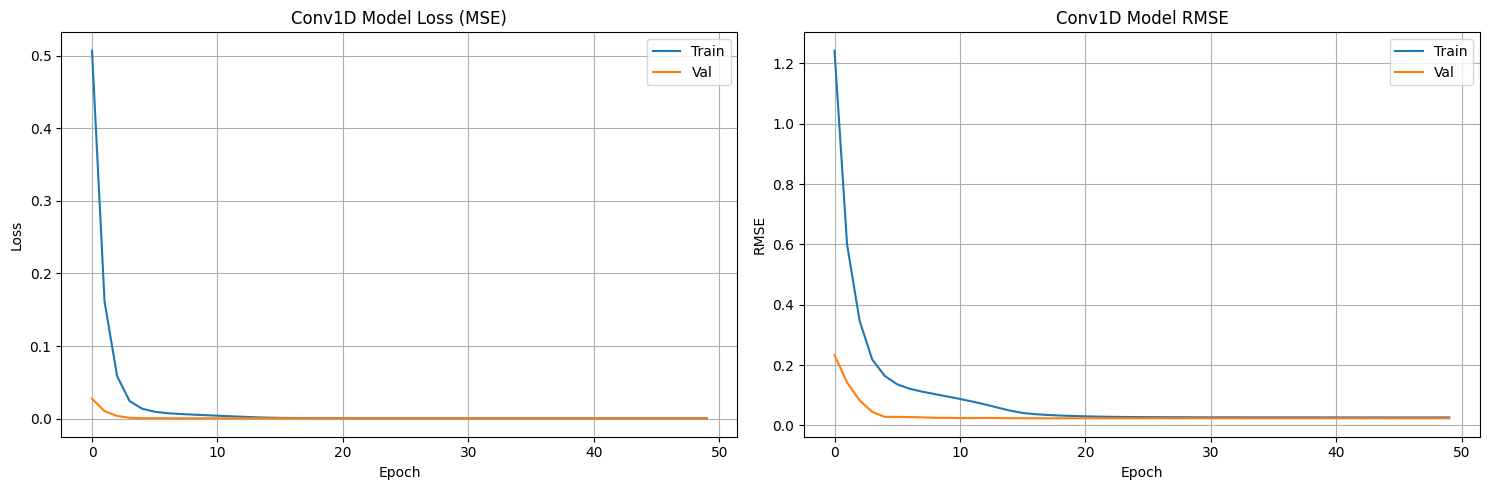

In [ ]:
"""Plots training and validation curves and saves them to the analytics directory."""

import matplotlib.pyplot as plt

ANALYTICS_DIR = "../analytics"
os.makedirs(ANALYTICS_DIR, exist_ok=True)


def plot_history(history):
    """Plots model loss and root mean squared error curves.

    Args:
        history: Keras History object.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss curve
    ax1.plot(history.history["loss"], label="Train")
    ax1.plot(history.history["val_loss"], label="Val")
    ax1.set_title("Conv1D Model Loss (MSE)")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    # RMSE curve
    ax2.plot(history.history["rmse"], label="Train")
    ax2.plot(history.history["val_rmse"], label="Val")
    ax2.set_title("Conv1D Model RMSE")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("RMSE")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(ANALYTICS_DIR, "conv1d_training_history.png"))
    plt.show()


if "history" in locals():
    plot_history(history)


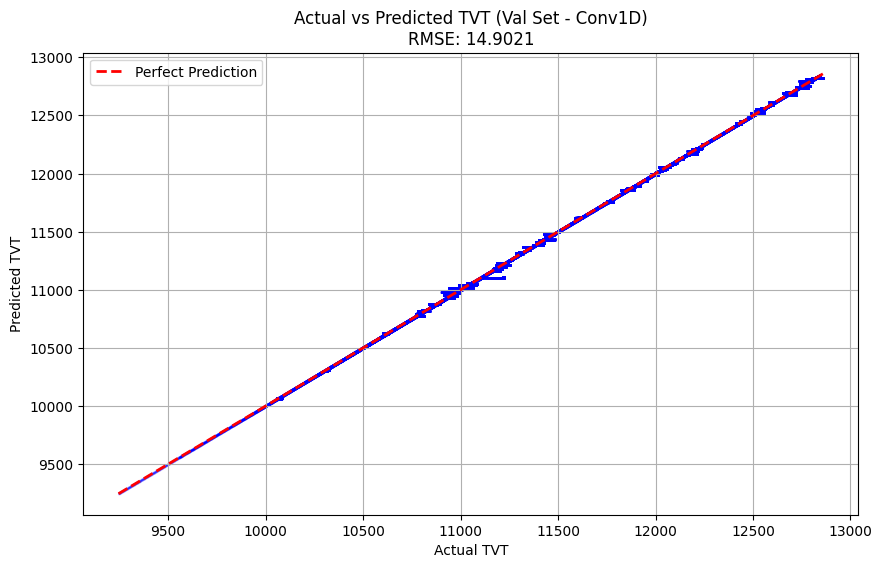

In [ ]:
def plot_pred_vs_actual(y_true, y_pred, val_rmse):
    """Plots predicted vs actual values on raw scale and saves it to analytics."""
    plt.figure(figsize=(10, 6))
    plt.scatter(np.array(y_true), np.array(y_pred), alpha=0.1, s=1, color="blue")

    # Draw perfect prediction line
    min_val = min(float(y_true.min()), float(y_pred.min()))
    max_val = max(float(y_true.max()), float(y_pred.max()))
    plt.plot(
        [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfect Prediction"
    )

    plt.title(f"Actual vs Predicted TVT (Val Set - Conv1D)\nRMSE: {val_rmse:.4f}")
    plt.xlabel("Actual TVT")
    plt.ylabel("Predicted TVT")
    plt.legend()
    plt.grid(True)

    plt.savefig(os.path.join(ANALYTICS_DIR, "conv1d_val_pred_vs_actual.png"))
    plt.show()


if "y_val_raw" in locals() and "yp_jnp" in locals():
    plot_pred_vs_actual(y_val_raw, yp_jnp, rmse)
